In [1]:
#!pip install seaborn
!pwd
#!ls


/home/zofia/Research/deep-bacterial-scores/Scripts/DatasetAssembly_archived


# Part 1: How was the data reorganised after downloading from RASP Atlas?

In [2]:
import re, ast, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
data_dir = Path("/home", "zofia", "Research", "datasetcreation", "data")

raw_dir = data_dir / "raw"
combined_dir = data_dir / "combined_datasets"
processed_dir = data_dir / "processed"



What do the files look like after being downloaded from RASP, and combined into per species CSVs?

In [5]:
bcereus_raw = pd.read_csv(combined_dir / "raw_b_cereus.csv")
bcereus_raw.head()

#smallest csv = best to test with

,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep3_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep2_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M23_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M20_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M23_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M21_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_refold_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M19_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M22_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M18_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M22_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep3_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M19_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep2_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M18_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M20_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M21_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_refold_rep2_Length100-pos.bw
0,"(4815588, 4815589, 7.973199844360352)","(4815588, 4815589, 0.0)","(4815588, 4815589, 2.6110000610351562)","(4815588, 4815589, 4.098800182342529)","(4815588, 4815589, 0.0)","(4815588, 4815589, 4.058800220489502)","(4815588, 4815589, 2.8647000789642334)","(4815588, 4815589, 0.0)","(4815588, 4815589, 1.2789000272750854)","(4815588, 4815589, 0.0)","(4815588, 4815589, 7.502699851989746)","(4815588, 4815589, 0.0)","(4815588, 4815589, 1.5942000150680542)","(4815588, 4815589, 3.8336000442504883)","(4815588, 4815589, 1.3137999773025513)","(4815588, 4815589, 4.944399833679199)","(4815588, 4815589, 10.780500411987305)","(4815588, 4815589, 4.636099815368652)","(4815588, 4815589, 6.492400169372559)","(4815588, 4815589, 3.662400007247925)"
1,"(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0

Each column is a filename from RASP with metadata information, and each cell is a string wrapped tuple of start position, end position, and score. 

In [4]:
bcereus = pd.read_csv(processed_dir / "b_cereus_processed.csv")
bcereus.head()


,Seq,Species,Method,Reagent,Temp,Condition,Specificity,Score,Coord,Study ID,Paper
0,AACTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGT...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,7.9732,4815588,2,Nature_Structural___Molecular_Biology (2016)
1,ACTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,0.0000,4815589,2,Nature_Structural___Molecular_Biology (2016)
2,CTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,8.3152,4815590,2,Nature_Structural___Molecular_Biology (2016)
3,TCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAAT...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,6.8731,4815591,2,Nature_Structural___Molecular_Biology (2016)
4,CCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAATA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,1.4723,4815592,2,Nature_Structural___Molecular_Biology (2016)


Now, the columns are features, and the seq of the 101 nts surrounding each score has also been pulled out using refseqs matching each species' recorded chromosome (apart from Y_pseudotuberculosis)

In [5]:
senterica = pd.read_csv(processed_dir / "s_enterica_processed.csv")
synechococcus = pd.read_csv(processed_dir / "synechococcus_processed.csv")
bsubtilis = pd.read_csv(processed_dir / "b_subtilis_processed.csv")
ypseudo = pd.read_csv(processed_dir / "y_pseudotuberculosis_processed.csv")
pputida = pd.read_csv(processed_dir / "p_putida_processed.csv")
ecoli = pd.read_csv(processed_dir / "e_coli_processed.csv")

/tmp/ipykernel_97498/995174918.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  ecoli = pd.read_csv(processed_dir / "e_coli_processed.csv")


count    1640.000000
mean        1.213939
std         2.363071
min         0.000000
25%         0.000000
50%         0.300250
75%         1.328150
max        24.963301
Name: Score, dtype: float64

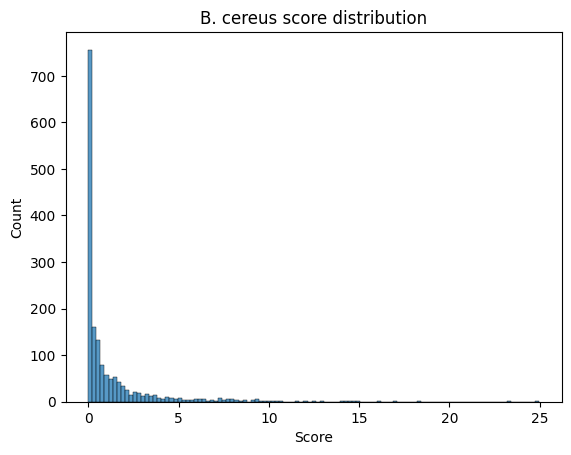

In [8]:
ax = sns.histplot(data=bcereus, x="Score")
ax.set_title("B. cereus score distribution")
bcereus["Score"].describe()

0    0.00000
1    0.18902
2    1.16217
3    0.29053
4    0.16328
Name: Score, dtype: float64
[0.03, 0.23, 0.25, 0.01, 7.89, 36.95, 54.64, 100.0]


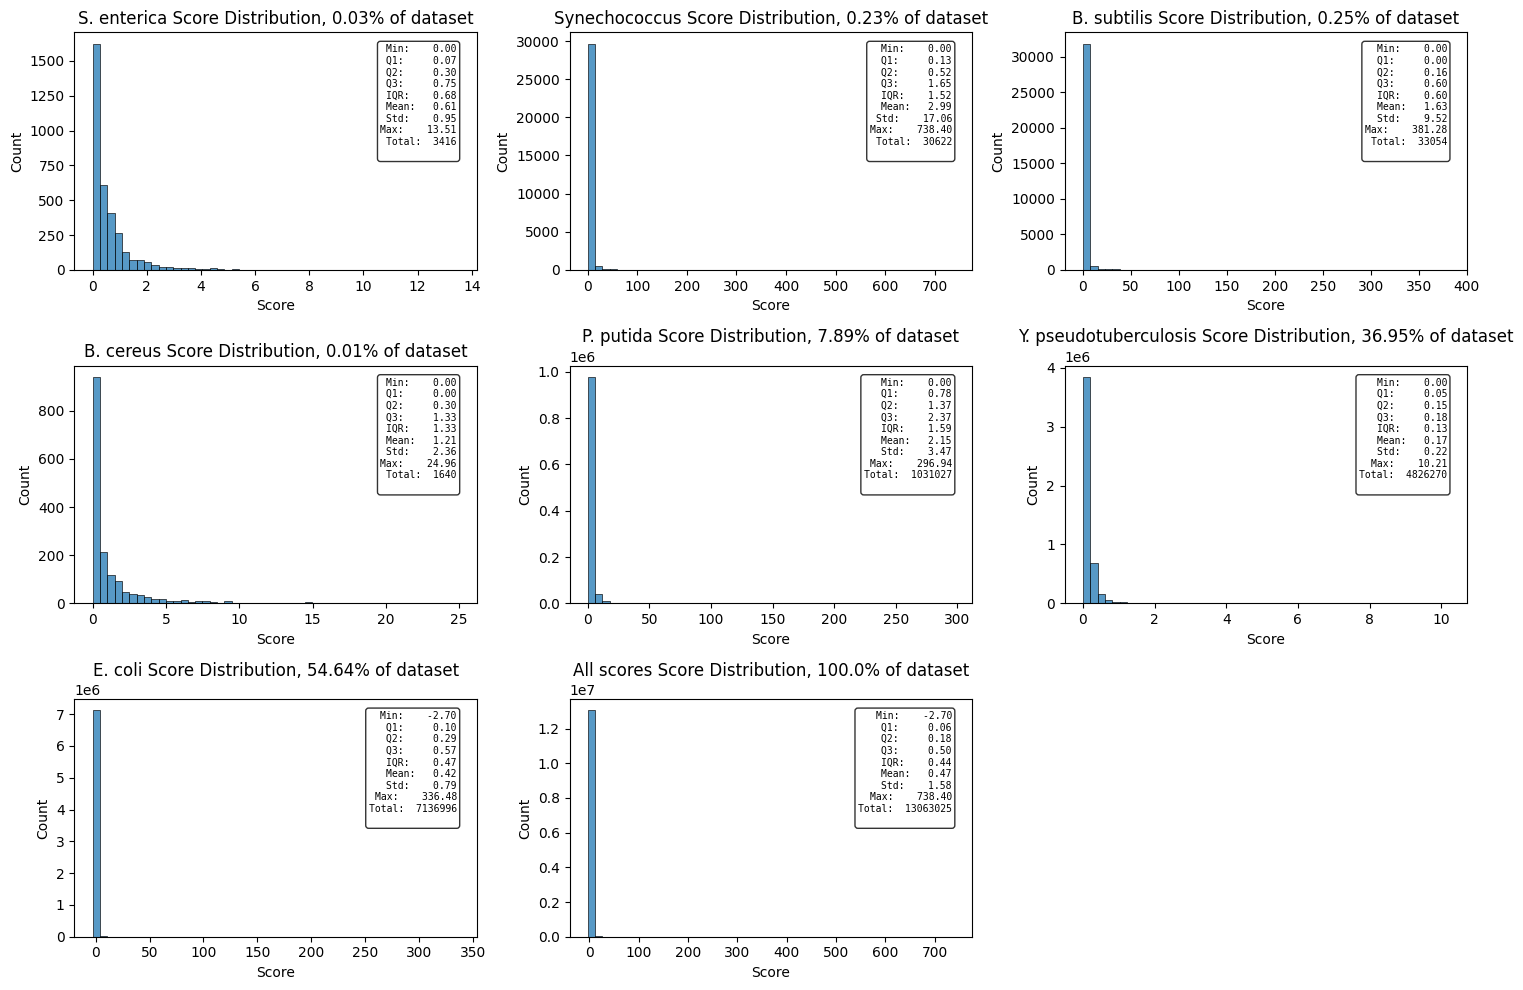

In [ ]:

dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo, ecoli]
names = ["S. enterica", "Synechococcus", "B. subtilis", "B. cereus", "P. putida", "Y. pseudotuberculosis", "E. coli"]

allscores = pd.concat([df["Score"] for df in dataframes], ignore_index=True) # A series of all the scores together to check distributions
print(allscores.head())

dataframes.append(allscores)
names.append("All scores")

percentages = [round((len(df)/len(allscores))*100, 2) for df in dataframes] # List of what % of total scores each df represents
print(percentages)

fig, axes = plt.subplots(3, 3, figsize=(15, 10)) 

axes = axes.flatten()

for i, df in enumerate(dataframes):
    if isinstance(df, pd.Series): # so it works for the allscores series
        scores = df
    else:
        scores = df["Score"]

    sns.histplot(data=scores, ax=axes[i], bins=50, kde=False)

    q1, q2, q3 = np.percentile(scores, [25, 50, 75])
    iqr = q3 - q1

    stats_text = (
        f"Min:    {scores.min():.2f}\n"
        f"Q1:     {q1:.2f}\n"
        f"Q2:     {q2:.2f}\n"
        f"Q3:     {q3:.2f}\n"
        f"IQR:    {iqr:.2f}\n"
        f"Mean:   {scores.mean():.2f}\n"
        f"Std:    {scores.std():.2f}\n"
        f"Max:    {scores.max():.2f}\n"
        f"Total:  {len(scores)}\n"
    )


    axes[i].text(
        0.95, 0.95, stats_text,
        transform=axes[i].transAxes,       
        verticalalignment="top",
        horizontalalignment="right",
        fontsize=7,
        fontfamily="monospace",        
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    
    axes[i].set_title(f'{names[i]} Score Distribution, {percentages[i]}% of dataset')


axes[8].set_visible(False)
plt.tight_layout()
plt.savefig('all_species_hists.png')
plt.show()


### B. cereus, Synechococcus, P. putida - slightly higher reactivity
A few outliers and the distribution maybe should be scaled down to live closer to the 0-1 range but overall as expected

### S. enterica - overall as expected
Some strange and high outliers, but the overall distribution looks good with most scores at zero but Q3 landing at 0.75: the threshold at which we expect nucleotides to be flexible

### B. subtilis, Y. pseudotuberculosis, E. coli - slightly lower reactivity
More zero values than distributions so far, and for all of these Q3 does not hit the reactivity threshold of 0.7
Y. pseutotuberculosis in particular has a very unreactive distribution. Check if this is to do with the technology used (Lead seq). 
E. coli is the only distribution with negative values, which will need to have a floor put on them to take them to 0. 

We will apply a standard normalising procedure, and see what that does to the skewedness of these. We will also investigate dropping "controls" - ie where no reagent was used





Within each species, there are various technologies used:

In [16]:
dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo, ecoli] #drop allscores

for i, df in enumerate(dataframes):
    ct = pd.crosstab(index=df["Method"], columns=[df["Paper"], df["Reagent"]], dropna=False)
    ct = ct.loc[:, (ct != 0).any()] #drop cols that are all zeroes
    ct.to_csv(f"crosstab_{names[i]}_beforenorm.csv")


    styled = (
        ct.style
        .set_table_styles([
            {"selector": "td, th",
             "props": [("border", "1px solid black"), ("padding", "5px")]},
        ])
        .set_caption(f'Methods and reagents in the combined {names[i]} dataset')
    )

    display(styled)





Paper,Biochemistry (2017)
Reagent,1M7
Method,
SHAPE-seq,3416


Paper,Nature_Structural___Molecular_Biology (2016)
Reagent,BZCN
Method,
Cotranscriptional_SHAPE-seq,1640


Paper,Nucleic_Acids_Research (2020)
Reagent,LEAD(II)
Method,
Lead-seq,4826270


35% of the Synechococcus dataset has no recorded reagent or method used. Checking the original paper, we see that:

5% of the P. putida dataset is the same. Checking the original paper:

With all of Y. pseudotuberculosis being Lead seq the unreactivity makes more sense. 

Finally, the E. coli data set has a small proportion (1%) of no-method-no-reactant scores in the Science(2016) dataset. Checking the original paper, we see that:

Let's replot the distributions, looking at the method rather than the species

In [7]:

dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo, ecoli]


# build some methods dfs

combined = pd.concat([df[["Score", "Method", "Reagent"]] for df in dataframes], ignore_index=True)

#now separate back out into methods

method_dfs = {name: group for name, group in combined.groupby("Method")}
print(method_dfs.keys())

#percentages = [round((len(df)/len(allscores))*100, 2) for df in dataframes] # List of what % of total scores each df represents
#print(percentages)


dict_keys(['Cotranscriptional_SHAPE-seq', 'DMS-MaPseq', 'DMS-seq', 'Lead-seq', 'RL-Seq', 'SHAPE-MaP', 'SHAPE-seq'])


In [12]:
print(method_dfs['RL-Seq'].head())

         Score  Method           Reagent
6182489  0.000  RL-Seq  HYDROXYL_RADICAL
6182490  1.000  RL-Seq  HYDROXYL_RADICAL
6182491  2.807  RL-Seq  HYDROXYL_RADICAL
6182492  5.170  RL-Seq  HYDROXYL_RADICAL
6182493  7.585  RL-Seq  HYDROXYL_RADICAL


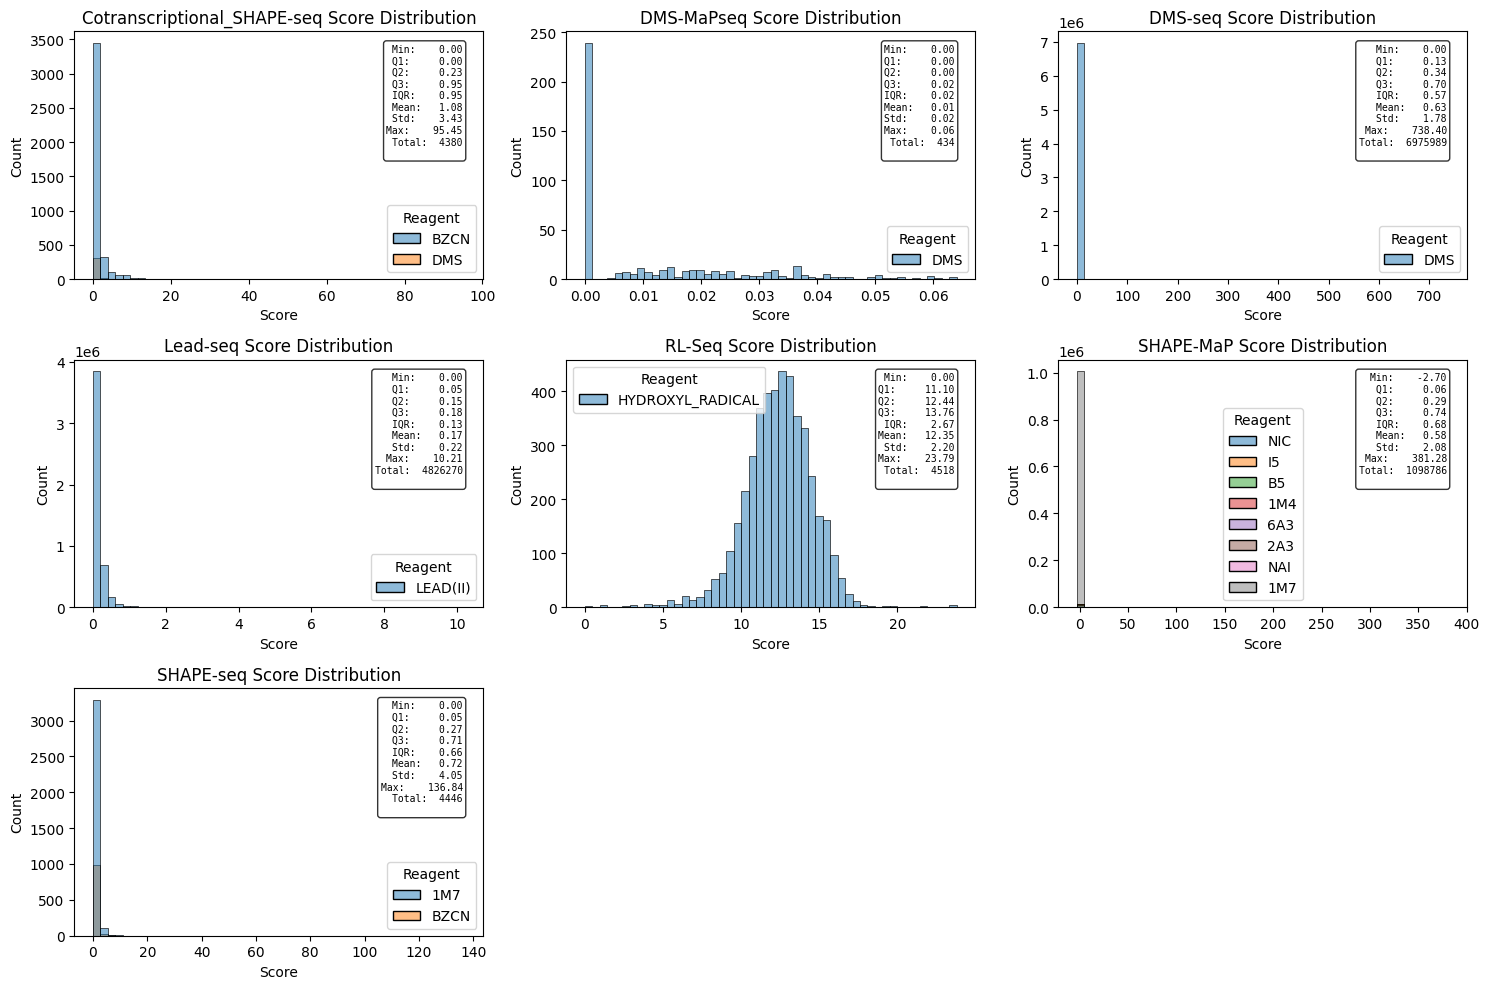

In [15]:

fig, axes = plt.subplots(3, 3, figsize=(15, 10)) 

axes = axes.flatten()

i = 0

for key in method_dfs.keys():

    
    df = method_dfs[key]

    sns.histplot(data=df, x="Score", hue="Reagent", ax=axes[i], bins=50, kde=False)

    scores = df["Score"]
    q1, q2, q3 = np.percentile(scores, [25, 50, 75])
    iqr = q3 - q1



    stats_text = (
        f"Min:    {scores.min():.2f}\n"
        f"Q1:     {q1:.2f}\n"
        f"Q2:     {q2:.2f}\n"
        f"Q3:     {q3:.2f}\n"
        f"IQR:    {iqr:.2f}\n"
        f"Mean:   {scores.mean():.2f}\n"
        f"Std:    {scores.std():.2f}\n"
        f"Max:    {scores.max():.2f}\n"
        f"Total:  {len(scores)}\n"
    )


    axes[i].text(
        0.95, 0.95, stats_text,
        transform=axes[i].transAxes,       
        verticalalignment="top",
        horizontalalignment="right",
        fontsize=7,
        fontfamily="monospace",        
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    
    axes[i].set_title(f'{key} Score Distribution')

    i = i+1

axes[7].set_visible(False)
axes[8].set_visible(False)
plt.tight_layout()
plt.savefig('all_methods_hists.png')
plt.show()


Both Lead-seq and RL-seq stand out as having different distributions. Note: while the DMS reactant in the co-transcriptional SHAPE seq histogram may look like an error, this was actually used in the study.



In [18]:
(82453+55055+10694)/13063025*100


1.1345151678114374

In [19]:
def normalise_scores(method_dfs):
    """
    Normalise reactivity scores following the 6-step procedure.
    
    Parameters:
        method_dfs: dict of dataframes with keys as method names,
                    each containing "Score", "Method", and "Reagent" columns.
    
    Returns:
        normalised: dict of normalised dataframes
        log: dict recording what was removed/changed at each step
    """
    log = {}
    
    # 1. Remove RL-seq
    if "RL-Seq" in method_dfs:
        log["rl_seq_removed"] = len(method_dfs["RL-Seq"])
        del method_dfs["RL-Seq"]
    
    normalised = {}
    
    for name, df in method_dfs.items():
        df = df.copy()  # Avoid modifying originals
        step_log = {"original_size": len(df)}
        
        # 2. Remove rows where both Method and Reagent are NaN
        both_nan = df["Method"].isna() & df["Reagent"].isna()
        step_log["nan_both_removed"] = both_nan.sum()
        df = df[~both_nan]
        
        # 3. Reassign negatives to 0
        negatives = df["Score"] < 0
        step_log["negatives_reassigned"] = negatives.sum()
        df.loc[negatives, "Score"] = 0
        
        # 4. Remove upper extremes above Q3 + 1.5*IQR
        q1 = df["Score"].quantile(0.25)
        q3 = df["Score"].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        outliers = df["Score"] > upper
        step_log["upper_outliers_removed"] = outliers.sum()
        step_log["upper_threshold"] = upper
        df = df[~outliers]
        
        # 5. Effective maximum reactivity (mean of top 8%)
        top_8_pct = df["Score"].quantile(0.92)  # Top 8% = above 92nd percentile
        top_scores = df.loc[df["Score"] >= top_8_pct, "Score"]
        effective_max = top_scores.mean()
        step_log["effective_max"] = effective_max
        
        # 6. Divide all scores by effective maximum
        if effective_max > 0:
            df["Score"] = df["Score"] / effective_max
        else:
            step_log["warning"] = "Effective max was 0, scores unchanged"
        
        step_log["final_size"] = len(df)
        normalised[name] = df
        log[name] = step_log
    
    return normalised, log

In [ ]:
normalised_dfs, log = normalise_scores(method_dfs)




rl_seq_removed:


AttributeError: 'int' object has no attribute 'items'

In [21]:
for name, info in log.items():
    print(f"\n{name}:")
    if isinstance(info, dict):
        for key, val in info.items():
            print(f"  {key}: {val}")
    else:
        print(f"  {info}")


rl_seq_removed:
  4518

Cotranscriptional_SHAPE-seq:
  original_size: 4380
  nan_both_removed: 0
  negatives_reassigned: 0
  upper_outliers_removed: 500
  upper_threshold: 2.3710000142455097
  effective_max: 1.8312096488437468
  final_size: 3880

DMS-MaPseq:
  original_size: 434
  nan_both_removed: 0
  negatives_reassigned: 0
  upper_outliers_removed: 15
  upper_threshold: 0.04999999888241276
  effective_max: 0.039764705716687054
  final_size: 419

DMS-seq:
  original_size: 6975989
  nan_both_removed: 0
  negatives_reassigned: 0
  upper_outliers_removed: 490507
  upper_threshold: 1.5449999570846558
  effective_max: 1.1115540218685807
  final_size: 6485482

Lead-seq:
  original_size: 4826270
  nan_both_removed: 0
  negatives_reassigned: 0
  upper_outliers_removed: 324371
  upper_threshold: 0.3714899960905314
  effective_max: 0.2973388785513757
  final_size: 4501899

SHAPE-MaP:
  original_size: 1098786
  nan_both_removed: 0
  negatives_reassigned: 159861
  upper_outliers_removed: 76797


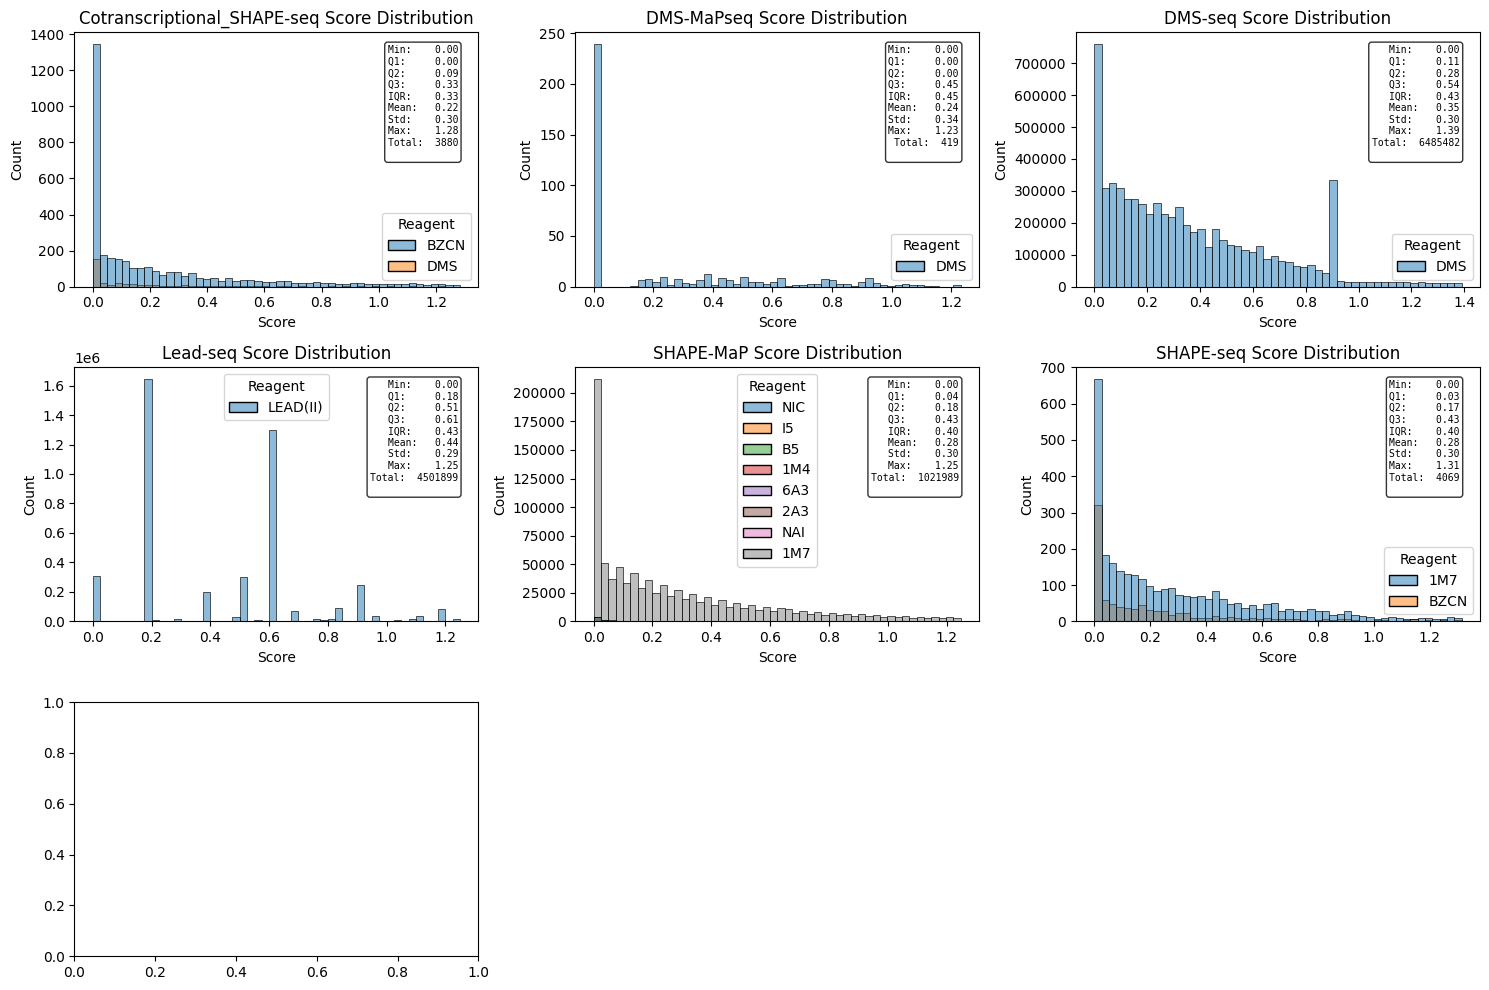

In [22]:

fig, axes = plt.subplots(3, 3, figsize=(15, 10)) 

axes = axes.flatten()

i = 0

for key in normalised_dfs.keys():

    
    df = normalised_dfs[key]

    sns.histplot(data=df, x="Score", hue="Reagent", ax=axes[i], bins=50, kde=False)

    scores = df["Score"]
    q1, q2, q3 = np.percentile(scores, [25, 50, 75])
    iqr = q3 - q1



    stats_text = (
        f"Min:    {scores.min():.2f}\n"
        f"Q1:     {q1:.2f}\n"
        f"Q2:     {q2:.2f}\n"
        f"Q3:     {q3:.2f}\n"
        f"IQR:    {iqr:.2f}\n"
        f"Mean:   {scores.mean():.2f}\n"
        f"Std:    {scores.std():.2f}\n"
        f"Max:    {scores.max():.2f}\n"
        f"Total:  {len(scores)}\n"
    )


    axes[i].text(
        0.95, 0.95, stats_text,
        transform=axes[i].transAxes,       
        verticalalignment="top",
        horizontalalignment="right",
        fontsize=7,
        fontfamily="monospace",        
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    
    axes[i].set_title(f'{key} Score Distribution')

    i = i+1

axes[7].set_visible(False)
axes[8].set_visible(False)
plt.tight_layout()
plt.savefig('all_methods_hists_normalised.png')
plt.show()


In [40]:
import gc

plt.close("all")  # Close all open figures
gc.collect()       # Force garbage collection

63005

Let's take a look at the distribution of the minority reactants

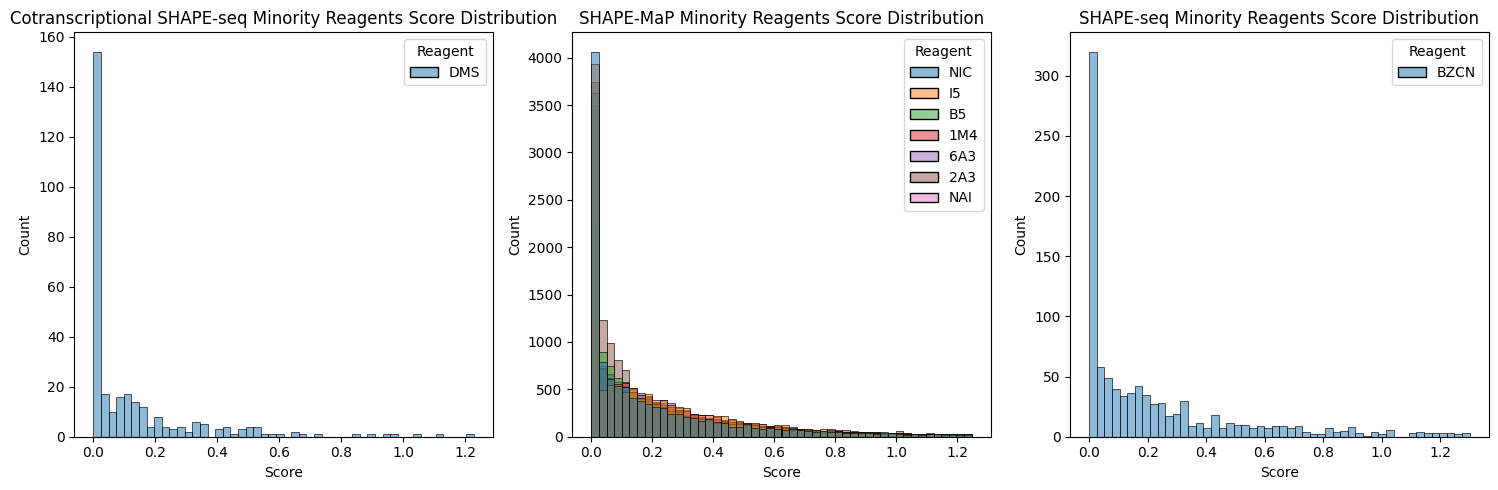

In [27]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) 

axes = axes.flatten()

sns.histplot(data=normalised_dfs['Cotranscriptional_SHAPE-seq'][normalised_dfs['Cotranscriptional_SHAPE-seq']["Reagent"] != "BZCN"], x="Score", hue="Reagent", ax=axes[0], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] != "1M7"], x="Score", hue="Reagent", ax=axes[1], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-seq'][normalised_dfs['SHAPE-seq']["Reagent"] != "1M7"], x="Score", hue="Reagent", ax=axes[2], bins=50, kde=False)

axes[0].set_title(f'Cotranscriptional SHAPE-seq Minority Reagents Score Distribution')
axes[1].set_title(f'SHAPE-MaP Minority Reagents Score Distribution')
axes[2].set_title(f'SHAPE-seq Minority Reagents Score Distribution')

plt.tight_layout()
plt.savefig('all_methods_hists_normalised_minority_reagents.png')
plt.show()


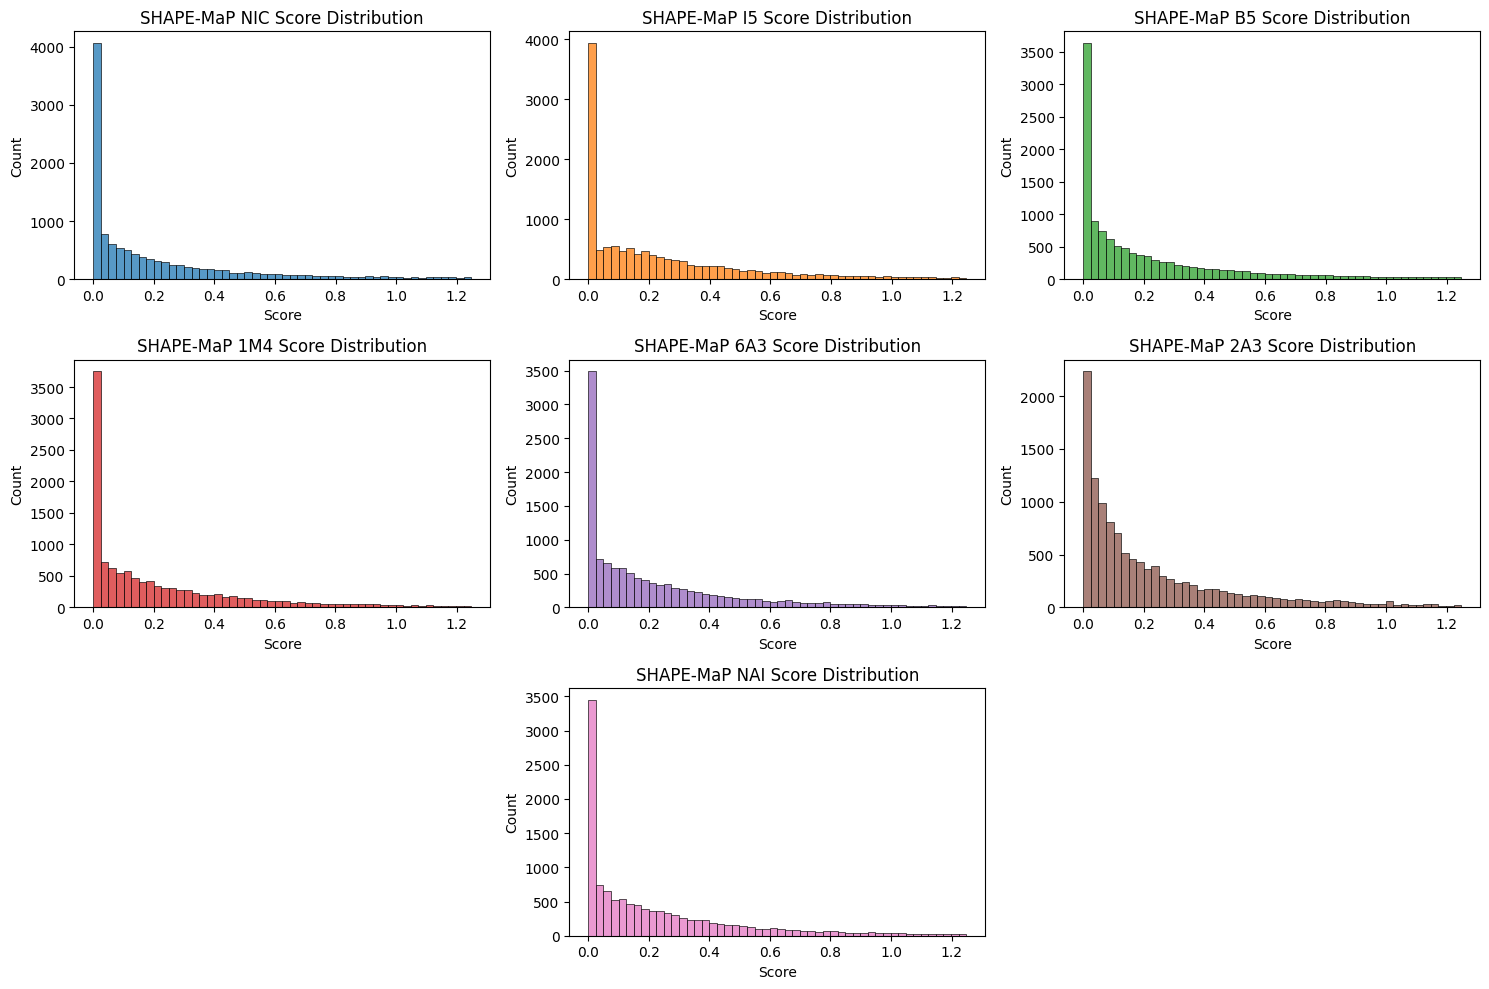

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10)) 

axes = axes.flatten()

sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "NIC"], x="Score", color="C0", ax=axes[0], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "I5"], x="Score", color="C1", ax=axes[1], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "B5"], x="Score", color="C2", ax=axes[2], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "1M4"], x="Score", color="C3", ax=axes[3], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "6A3"], x="Score", color="C4", ax=axes[4], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "2A3"], x="Score", color="C5", ax=axes[5], bins=50, kde=False)
sns.histplot(data=normalised_dfs['SHAPE-MaP'][normalised_dfs['SHAPE-MaP']["Reagent"] == "NAI"], x="Score", color="C6", ax=axes[7], bins=50, kde=False)

axes[0].set_title(f'SHAPE-MaP NIC Score Distribution')
axes[1].set_title(f'SHAPE-MaP I5 Score Distribution')
axes[2].set_title(f'SHAPE-MaP B5 Score Distribution')
axes[3].set_title(f'SHAPE-MaP 1M4 Score Distribution')
axes[4].set_title(f'SHAPE-MaP 6A3 Score Distribution')
axes[5].set_title(f'SHAPE-MaP 2A3 Score Distribution')
axes[7].set_title(f'SHAPE-MaP NAI Score Distribution')

axes[6].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.savefig('SHAPE-MaP_hists_normalised_minority_reagents.png')
plt.show()

## Binning scores: comparison of Bliss et. al vs this project's

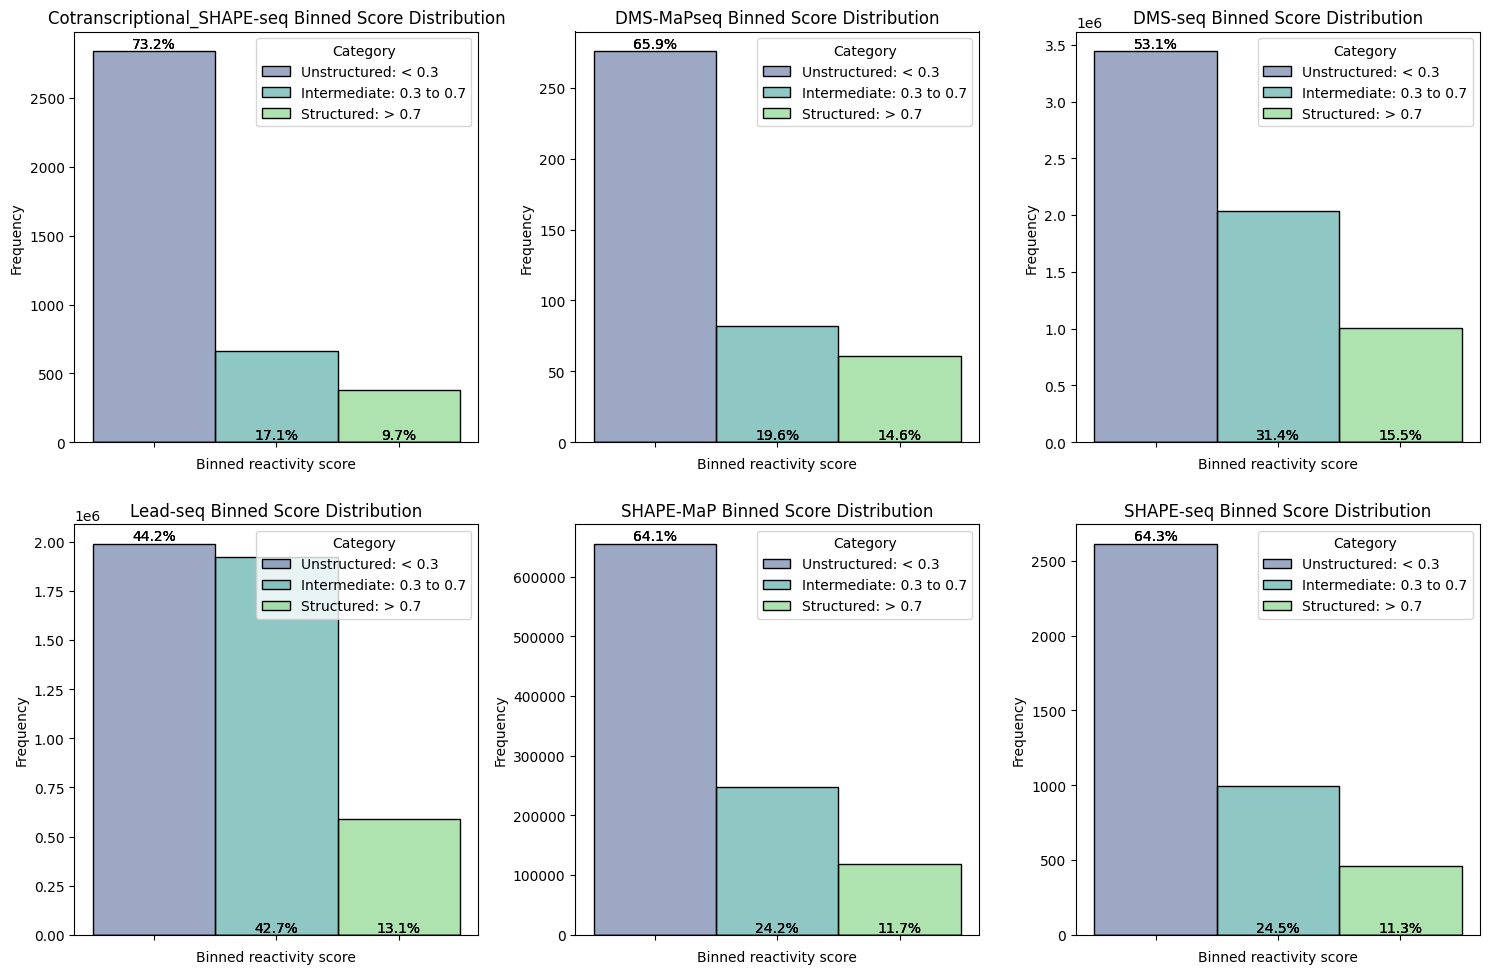

In [45]:
#structure scores are binned into {unstructured, intermediate, structured}
#following the R function bin_SHAPE_data (min=-0.7, max=0.33)

negative_infinity = float('-inf')
infinity = float('inf')

bin_edges = [0, 0.3, 0.7, infinity]
bin_labels = ["Unstructured: < 0.3", "Intermediate: 0.3 to 0.7", "Structured: > 0.7"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

axes = axes.flatten()

i = 0

for key in normalised_dfs.keys():

    
    df = normalised_dfs[key]

    #Categorising data for equal widths of hist plot
    df['Category'] = pd.cut(df['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    sns.histplot(data=df, x="Category", hue="Category", ax=axes[i], palette='viridis')

    #Displaying the % of each category
    counts = df['Category'].value_counts(normalize=True) * 100

    pct_labels = [f'{p:.1f}%' for p in counts.sort_index()]

    for container in axes[i].containers:
        axes[i].bar_label(axes[i].containers[-1], labels=pct_labels)

    axes[i].set_xticklabels([]) 
    axes[i].set_title(f'{key} Binned Score Distribution')
    axes[i].set_xlabel('Binned reactivity score')
    axes[i].set_ylabel('Frequency')

    i = i+1

plt.tight_layout()
plt.savefig('all_methods_normalised_new_categories.png')
plt.show()


In [ ]:
#Categorising data for equal widths of hist plot
ecoli['Category'] = pd.cut(ecoli['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)

sns.countplot(data=ecoli, x='Category', palette='viridis')

plt.xlabel('Binned reactivity score')
plt.ylabel('Frequency')
plt.title('E coli binned scores')
plt.show()

In [21]:
ecoli["Paper"].value_counts()

Paper
eLife (2017)                                    5806082
Cell (2018)                                     1007861
Science (2016)                                   256460
Nucleic_Acids_Research (2021)                     60365
RNA_Biology (2022)                                 4518
Molecular_Cell (2021)                               912
Nature_Structural___Molecular_Biology (2016)        798
Name: count, dtype: int64

/tmp/ipykernel_96361/385861990.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=mustoecategories, palette='viridis')


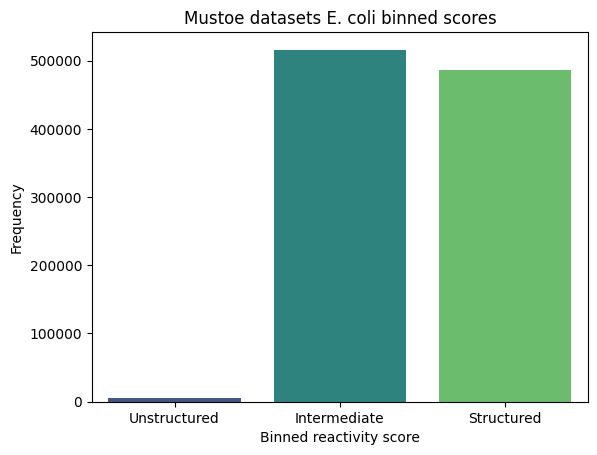

In [24]:
#Now, ONLY looking at the mustoe data that deepshape.ecoli is trained on
mustoescores = ecoli[ecoli["Paper"] == "Cell (2018)"]["Score"]

#Categorising data for equal widths of hist plot
mustoecategories = pd.cut(mustoescores, bins=bin_edges, labels=bin_labels, include_lowest=True)

sns.countplot(x=mustoecategories, palette='viridis')

plt.xlabel('Binned reactivity score')
plt.ylabel('Frequency')
plt.title('Mustoe datasets E. coli binned scores')
plt.show()

/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

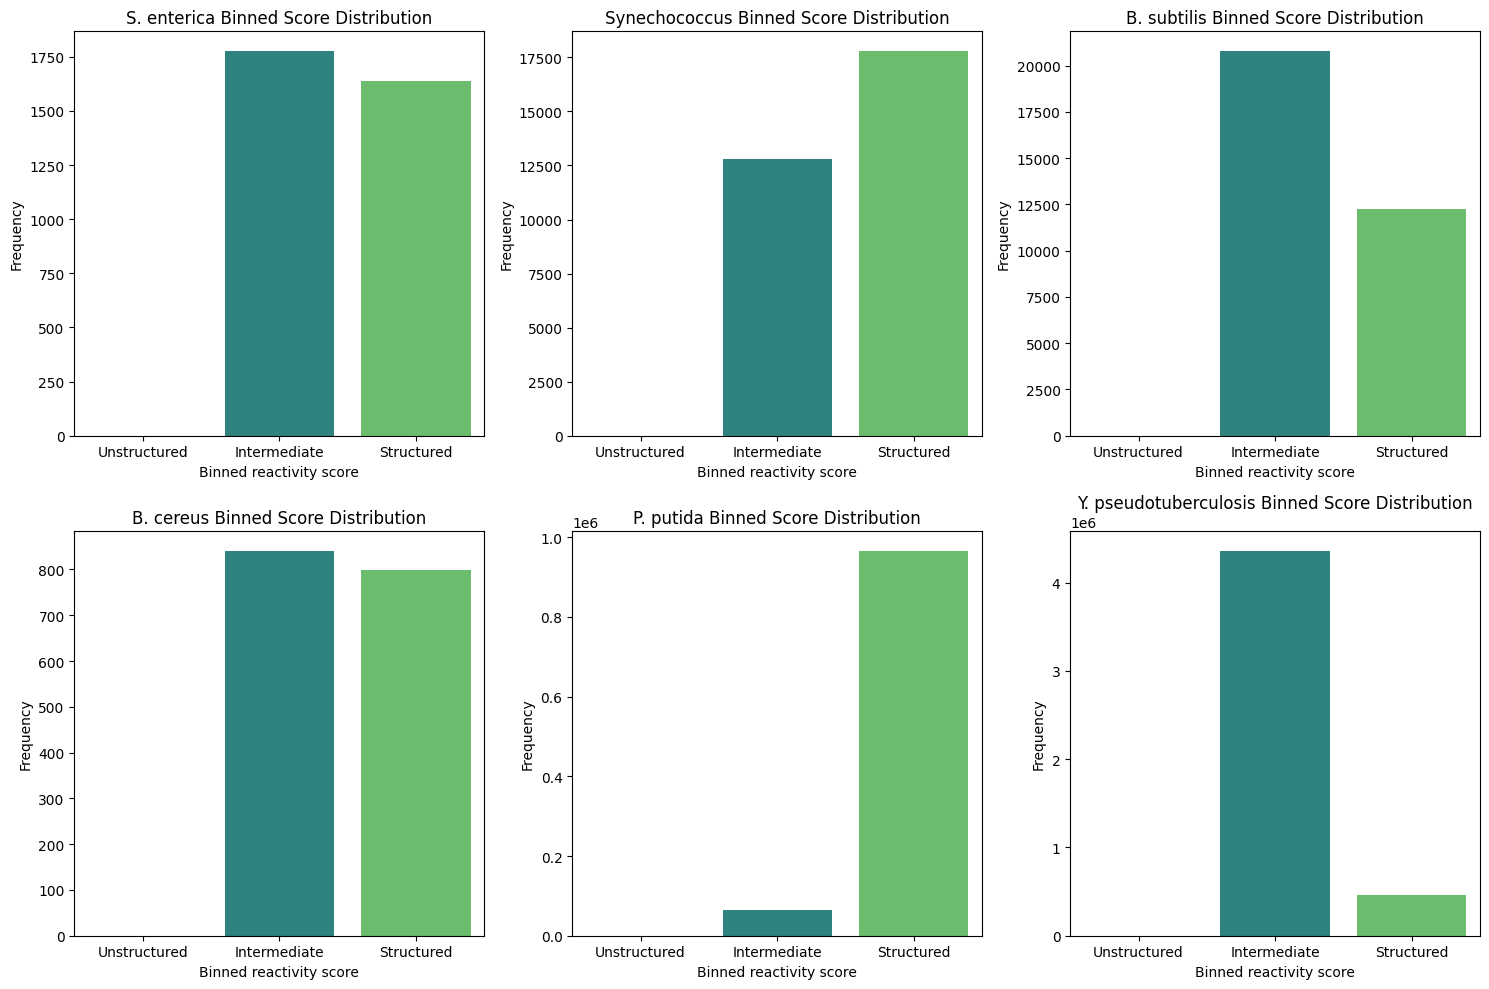

In [18]:
#dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo]
#names = ["S. enterica", "Synechococcus", "B. subtilis", "B. cereus", "P. putida", "Y. pseudotuberculosis"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, df in enumerate(dataframes):
    df['Category'] = pd.cut(df['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)
    sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])

    axes[i].set_xlabel('Binned reactivity score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{names[i]} Binned Score Distribution')


plt.tight_layout()
plt.show()
